# Full Replication Notebook - NASA C-MAPSS

This notebook reproduces the models discussed in Seixas Leal et al. (2025):

- SGD Regression
- SVR
- 1D CNN
- CNN-LSTM
- BiLSTM
- BiLSTM + Feature Attention
- BiLSTM + Temporal Attention
- BiLSTM-Attn

Each run is saved under `results/runs/<run_id>/`. The global `results/metrics.csv` file is updated when it is not locked by another application.

## 1. Setup

In [ ]:
from pathlib import Path
import subprocess
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PYTHON = PROJECT_ROOT / '.venv-codex' / 'Scripts' / 'python.exe'
if not PYTHON.exists():
    PYTHON = Path(sys.executable)

RESULTS_DIR = PROJECT_ROOT / 'results'
RUNS_DIR = RESULTS_DIR / 'runs'

print('Project root:', PROJECT_ROOT)
print('Python executable:', PYTHON)
print('Results directory:', RESULTS_DIR)

## 2. Check Dataset And Preprocessing

In [ ]:
from rul_replication.data import load_cmapss

for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_cmapss(fd, window_size=30, clip_rul=125)
    print(fd, 'train', d.train_windows.shape, 'test', d.test_windows.shape, 'features', len(d.feature_names))

## 3. Experiment Configuration

For the first manual run, keep `DATASETS = ['FD001']`. After validating the pipeline, switch to all four subsets.

In [ ]:
# Edit these variables depending on the experiment scope.
DATASETS = ['FD001']
# DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

MODEL_CONFIGS = {
    'sgd': {'epochs': 0, 'batch_size': 0},
    'svr': {'epochs': 0, 'batch_size': 0},
    'cnn': {'epochs': 50, 'batch_size': 128},
    'cnn_lstm': {'epochs': 50, 'batch_size': 128},
    'bilstm': {'epochs': 80, 'batch_size': 256},
    'bilstm_feature_attn': {'epochs': 80, 'batch_size': 256},
    'bilstm_temporal_attn': {'epochs': 80, 'batch_size': 256},
    'bilstm_attn': {'epochs': 80, 'batch_size': 256},
}

# Recommended order: baselines first, deep learning models afterwards.
MODELS_TO_RUN = [
    'sgd',
    'svr',
    'cnn',
    'cnn_lstm',
    'bilstm',
    'bilstm_feature_attn',
    'bilstm_temporal_attn',
    'bilstm_attn',
]

COMMON_ARGS = {
    'window_size': 30,
    'clip_rul': 125,
    'seed': 42,
    'lr': 3e-4,
    'weight_decay': 1e-4,
    'patience': 10,
    'val_fraction': 0.2,
    'hidden_size': 64,
    'dropout': 0.3,
}

print('Datasets:', DATASETS)
print('Models:', MODELS_TO_RUN)

## 4. Helper Function For One Experiment

Each run creates a dedicated artifact folder, for example `results/runs/FD001_cnn_lstm_final/`.

In [ ]:
def run_one(fd, model, suffix='final'):
    cfg = MODEL_CONFIGS[model]
    run_name = f'{fd}_{model}_{suffix}'
    cmd = [
        str(PYTHON), str(PROJECT_ROOT / 'run_experiment.py'),
        '--fd', fd,
        '--model', model,
        '--window-size', str(COMMON_ARGS['window_size']),
        '--clip-rul', str(COMMON_ARGS['clip_rul']),
        '--seed', str(COMMON_ARGS['seed']),
        '--run-name', run_name,
    ]
    if cfg['epochs'] > 0:
        cmd += [
            '--epochs', str(cfg['epochs']),
            '--batch-size', str(cfg['batch_size']),
            '--lr', str(COMMON_ARGS['lr']),
            '--weight-decay', str(COMMON_ARGS['weight_decay']),
            '--patience', str(COMMON_ARGS['patience']),
            '--val-fraction', str(COMMON_ARGS['val_fraction']),
            '--hidden-size', str(COMMON_ARGS['hidden_size']),
            '--dropout', str(COMMON_ARGS['dropout']),
        ]
    print('\n' + '=' * 90)
    print('RUN:', fd, model)
    print('CMD:', ' '.join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
    return RUNS_DIR / run_name

def load_run_metrics(run_dir):
    with open(run_dir / 'metrics.json', encoding='utf-8') as f:
        return json.load(f)

## 5. Run Baselines First

This cell is relatively fast. It validates the end-to-end pipeline and creates SGD/SVR baseline results.

## Existing Results Are Already Saved

The previous training results are preserved under `results/runs/`. To view them again, run Sections 7-11 only. Do not rerun Sections 5-6 unless you intentionally want to train the models again.

In [ ]:
baseline_runs = []
for fd in DATASETS:
    for model in ['sgd', 'svr']:
        if model in MODELS_TO_RUN:
            baseline_runs.append(run_one(fd, model))

pd.DataFrame([load_run_metrics(p) for p in baseline_runs]) if baseline_runs else pd.DataFrame()

## 6. Run Deep Learning Models

This cell trains the deep learning models selected in `MODELS_TO_RUN` for each dataset listed in `DATASETS`.

The cell iterates through the following model list:

- `cnn`: 1D CNN baseline for extracting local temporal patterns.
- `cnn_lstm`: hybrid CNN-LSTM baseline reported in the paper.
- `bilstm`: plain Bidirectional LSTM without attention.
- `bilstm_feature_attn`: BiLSTM with feature-level attention only.
- `bilstm_temporal_attn`: BiLSTM with temporal attention only.
- `bilstm_attn`: the proposed dual-attention BiLSTM-inspired model.

For each selected model, the notebook calls `run_one(fd, model)`, which internally runs `run_experiment.py` with the configuration defined in `MODEL_CONFIGS` and `COMMON_ARGS`.

Each completed run is saved under:

`results/runs/<FD>_<model>_final/`

Each run folder contains:

- `config.json`: preprocessing, model, and training configuration.
- `metrics.json`: RMSE, NASA Score, R2, rRMSE, KGE, and paper comparison if available.
- `predictions.csv`: predicted RUL and true RUL for each test engine.
- `training_history.csv`: train/validation loss per epoch for PyTorch models.
- `checkpoint.pt`: saved PyTorch model weights.

This cell can take a long time, especially for FD002-FD004 and BiLSTM-based models. For a first replication run, it is recommended to keep `DATASETS = ['FD001']`. If you want to run only one or two models, edit `MODELS_TO_RUN` in Section 3 before running this cell.

In [ ]:
deep_runs = []
deep_models = [
    'cnn',
    'cnn_lstm',
    'bilstm',
    'bilstm_feature_attn',
    'bilstm_temporal_attn',
    'bilstm_attn',
]

for fd in DATASETS:
    for model in deep_models:
        if model in MODELS_TO_RUN:
            deep_runs.append(run_one(fd, model))

pd.DataFrame([load_run_metrics(p) for p in deep_runs]) if deep_runs else pd.DataFrame()

## 7. Aggregate Results From Run Folders

This cell reads `results/runs/*/metrics.json` directly, so it does not depend on whether `results/metrics.csv` is locked by another application.

In [1]:
records = []
for metrics_path in sorted(RUNS_DIR.glob('*/metrics.json')):
    with open(metrics_path, encoding='utf-8') as f:
        row = json.load(f)
    row['run_dir'] = str(metrics_path.parent)
    records.append(row)

all_runs = pd.DataFrame(records)
all_runs.tail(20)

,run_id,fd,model,window_size,clip_rul,include_settings,seed,epochs,batch_size,lr,weight_decay,patience,val_fraction,hidden_size,dropout,rmse,nasa_score,r2,rrmse,kge,paper_rmse,rmse_delta_vs_paper,run_dir,model_order,paper_model_name
6,FD001_sgd_final,FD001,sgd,30,125,False,42,,,,,,,,,15.910584,401.487468,0.853407,21.068040,0.887578,,,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_sgd_final,0,SGD
7,FD001_svr_final,FD001,svr,30,125,False,42,,,,,,,,,19.726635,893.114372,0.774656,26.121074,0.792935,,,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_svr_final,1,SVR
4,FD001_cnn_final,FD001,cnn,30,125,False,42,50,128,0.0003,0.0001,10,0.2,64,0.3,21.605428,4095.240020,0.729687,28.608882,0.837999,,,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_cnn_final,2,1D CNN
5,FD001_cnn_lstm_final,FD001,cnn_lstm,30,125,False,42,50,128,0.0003,0.0001,10,0.2,64,0.3,19.280665,523.366580,0.784730,25.530541,0.746988,16.33,2.950665,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_cnn_lstm_final,3,CNN-LSTM
2,FD001_bilstm_final,FD001,bilstm,30,125,False,42,80,256,0.0003,0.0001,10,0.2,64,0.3,20.068608,834.033956,0.766775,26.573899,0.879465,,,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_final,4,BiLSTM
1,FD001_bilstm_feature_attn_final,FD001,bilstm_feature_attn,30,125,False,42,80,256,0.0003,0.0001,10,0.2,64,0.3,20.058041,847.528575,0.767021,26.559907,0.866249,,,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_feature_attn_final,5,BiLSTM + Feature Attention
3,FD001_bilstm_temporal_attn_final,FD001,bilstm_temporal_attn,30,125,False,42,80,256,0.0003,0.0001,10,0.2,64,0.3,18.615481,661.577093,0.799327,24.649736,0.889842,,,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_temporal_attn_final,6,BiLSTM + Temporal Attention
0,FD001_bilstm_attn_final,FD001,bilstm_attn,30,125,False,42,80,256,0.0003,0.0001,10,0.2,64,0.3,17.852220,584.913911,0.815445,23.639063,0.895194,13.12,4.73222,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_attn_final,7,BiLSTM-Attn


## 8. Compare With The Paper

The paper provides RMSE values for CNN-LSTM and BiLSTM-Attn on FD001-FD004. Other models are still shown, but `paper_rmse` is blank when no reference value is stored in the code.

In [2]:
paper_names = {
    'sgd': 'SGD',
    'svr': 'SVR',
    'cnn': '1D CNN',
    'cnn_lstm': 'CNN-LSTM',
    'bilstm': 'BiLSTM',
    'bilstm_feature_attn': 'BiLSTM + Feature Attention',
    'bilstm_temporal_attn': 'BiLSTM + Temporal Attention',
    'bilstm_attn': 'BiLSTM-Attn',
}

if len(all_runs):
    final = all_runs[all_runs['fd'].isin(DATASETS) & all_runs['model'].isin(MODELS_TO_RUN)].copy()
    final['paper_model_name'] = final['model'].map(paper_names)
    final = final.sort_values('run_id').drop_duplicates(subset=['fd', 'model'], keep='last')
    cols = [
        'fd', 'paper_model_name', 'model', 'epochs', 'batch_size', 'rmse', 'paper_rmse',
        'rmse_delta_vs_paper', 'r2', 'rrmse', 'kge', 'nasa_score', 'run_id', 'run_dir'
    ]
    comparison = final[cols].sort_values(['fd', 'model'])
    comparison.to_csv(RESULTS_DIR / 'comparison_full.csv', index=False)
    display(comparison)
else:
    comparison = pd.DataFrame()
    print('No run metrics found yet.')

,fd,paper_model_name,model,epochs,batch_size,rmse,paper_rmse,rmse_delta_vs_paper,r2,rrmse,kge,nasa_score,run_id,run_dir
2,FD001,BiLSTM,bilstm,80,256,20.068608,,,0.766775,26.573899,0.879465,834.033956,FD001_bilstm_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_final
0,FD001,BiLSTM-Attn,bilstm_attn,80,256,17.852220,13.12,4.73222,0.815445,23.639063,0.895194,584.913911,FD001_bilstm_attn_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_attn_final
1,FD001,BiLSTM + Feature Attention,bilstm_feature_attn,80,256,20.058041,,,0.767021,26.559907,0.866249,847.528575,FD001_bilstm_feature_attn_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_feature_attn_final
3,FD001,BiLSTM + Temporal Attention,bilstm_temporal_attn,80,256,18.615481,,,0.799327,24.649736,0.889842,661.577093,FD001_bilstm_temporal_attn_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_bilstm_temporal_attn_final
4,FD001,1D CNN,cnn,50,128,21.605428,,,0.729687,28.608882,0.837999,4095.240020,FD001_cnn_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_cnn_final
5,FD001,CNN-LSTM,cnn_lstm,50,128,19.280665,16.33,2.950665,0.784730,25.530541,0.746988,523.366580,FD001_cnn_lstm_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_cnn_lstm_final
6,FD001,SGD,sgd,,,15.910584,,,0.853407,21.068040,0.887578,401.487468,FD001_sgd_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_sgd_final
7,FD001,SVR,svr,,,19.726635,,,0.774656,26.121074,0.792935,893.114372,FD001_svr_final,C:\UIT\Nghiên cứu khoa học\Rebuild_paper_models\results\runs\FD001_svr_final


## 9. RMSE Pivot Table

In [14]:
if len(comparison):
    rmse_pivot = comparison.pivot(index='model', columns='fd', values='rmse')
    display(rmse_pivot)
    rmse_pivot.to_csv(RESULTS_DIR / 'rmse_pivot_full.csv')

fd,FD001
model,
bilstm,20.068608
bilstm_attn,17.852220
bilstm_feature_attn,20.058041
bilstm_temporal_attn,18.615481
cnn,84.928653
cnn_lstm,19.280665
sgd,15.910584
svr,19.726635


## 10. Plot Predictions For One Run

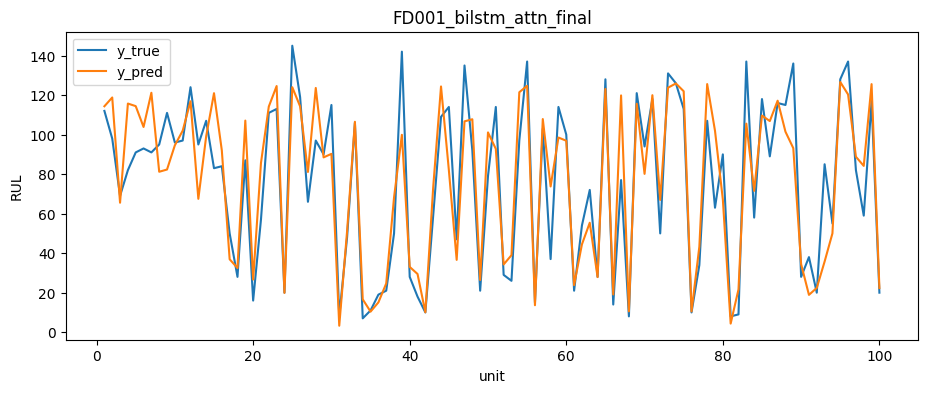

,unit,y_true,y_pred
0,1,112.0,114.355530
1,2,98.0,118.802063
2,3,69.0,65.533554
3,4,82.0,115.725342
4,5,91.0,114.422882
5,6,93.0,103.877312
6,7,91.0,121.180069
7,8,95.0,81.200478
8,9,111.0,82.336960
9,10,96.0,94.597626


In [12]:
# Change this run name to inspect another run.
RUN_TO_PLOT = 'FD001_bilstm_attn_final'
pred_path = RUNS_DIR / RUN_TO_PLOT / 'predictions.csv'

if pred_path.exists():
    pred = pd.read_csv(pred_path)
    ax = pred.plot(x='unit', y=['y_true', 'y_pred'], figsize=(11, 4), title=RUN_TO_PLOT)
    ax.set_ylabel('RUL')
    plt.show()
    display(pred.head(10))
else:
    print('Prediction file not found:', pred_path)

## 11. Plot Training History

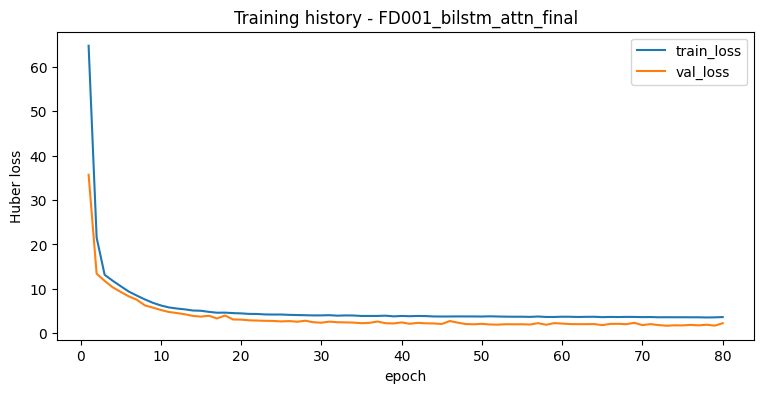

,epoch,train_loss,val_loss
75,76,3.607511,1.895082
76,77,3.607004,1.790759
77,78,3.565220,1.931945
78,79,3.594033,1.723659
79,80,3.655562,2.264115


In [13]:
history_path = RUNS_DIR / RUN_TO_PLOT / 'training_history.csv'
if history_path.exists():
    hist = pd.read_csv(history_path)
    ax = hist.plot(x='epoch', y=['train_loss', 'val_loss'], figsize=(9, 4), title=f'Training history - {RUN_TO_PLOT}')
    ax.set_ylabel('Huber loss')
    plt.show()
    display(hist.tail())
else:
    print('Training history not found:', history_path)

## 12. Report Notes

After the full run, inspect `comparison_full.csv` and discuss:

- Which model is closest to the paper by RMSE.
- Which model has the best or worst NASA Score.
- Whether BiLSTM-Attn outperforms CNN-LSTM in this replication.
- If results differ from the paper: random seed, validation split, RUL clipping, window size, Optuna tuning, TensorFlow versus PyTorch implementation, batch size, hidden size, and the fact that the paper does not release code.